In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel('/Users/karandangi/Downloads/online retail/Data/clean_data.xlsx')

In [4]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,39.6,2009-12
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,59.5,2009-12
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,30.6,2009-12
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom,45.0,2009-12


In [5]:
df.shape

(406430, 10)

# Customer Cohort & RFM Analysis

## Objective

The objective of this notebook is to understand customer purchasing behavior beyond overall sales performance.

This analysis focuses on two key areas:

- **Cohort Analysis** to measure customer retention over time.
- **RFM Segmentation** to identify valuable customer groups based on purchase recency, purchase frequency, and monetary value.

These analyses help answer questions such as:

- Do customers return after their first purchase?
- Which customer cohorts have the highest retention?
- Which customers are the most valuable?
- Which customers are at risk of churning?
- Which customer segments should receive targeted marketing campaigns?

In [6]:
df.groupby('Customer ID')['Month'].min()

Customer ID
12346    2009-12
12347    2010-10
12348    2010-09
12349    2010-04
12351    2010-11
          ...   
18283    2010-02
18284    2010-10
18285    2010-02
18286    2009-12
18287    2010-05
Name: Month, Length: 4286, dtype: str

In [7]:
df["CohortMonth"] = (df.groupby("Customer ID")["InvoiceDate"].transform("min").dt.to_period("M"))

In [8]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,CohortMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12,2009-12
...,...,...,...,...,...,...,...,...,...,...,...
406425,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom,5.90,2010-12,2009-12
406426,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,2009-12
406427,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,2009-12
406428,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom,7.50,2010-12,2009-12


In [9]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

In [10]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,CohortMonth,InvoiceMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12,2009-12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,2009-12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,2009-12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12,2009-12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12,2009-12,2009-12
...,...,...,...,...,...,...,...,...,...,...,...,...
406425,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom,5.90,2010-12,2009-12,2010-12
406426,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,2009-12,2010-12
406427,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,2009-12,2010-12
406428,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom,7.50,2010-12,2009-12,2010-12


In [11]:
df["CohortIndex"] = ((df["InvoiceMonth"].dt.year - df["CohortMonth"].dt.year) * 12 + 
                     (df["InvoiceMonth"].dt.month - df["CohortMonth"].dt.month))

In [12]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,CohortMonth,InvoiceMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12,2009-12,2009-12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406425,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530,United Kingdom,5.90,2010-12,2009-12,2010-12,12
406426,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,2009-12,2010-12,12
406427,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530,United Kingdom,3.75,2010-12,2009-12,2010-12,12
406428,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530,United Kingdom,7.50,2010-12,2009-12,2010-12,12


In [13]:
cohort_data = (df.groupby(["CohortMonth", "CohortIndex"])["Customer ID"].nunique().reset_index(name="Customers"))
cohort_data

,CohortMonth,CohortIndex,Customers
0,2009-12,0,952
1,2009-12,1,334
2,2009-12,2,317
3,2009-12,3,405
4,2009-12,4,360
...,...,...,...
86,2010-10,1,97
87,2010-10,2,35
88,2010-11,0,326
89,2010-11,1,35


In [14]:
# final pivot table
cohort_table = cohort_data.pivot(index="CohortMonth",columns="CohortIndex",values="Customers")
cohort_table

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2009-12,952.0,334.0,317.0,405.0,360.0,342.0,359.0,327.0,321.0,344.0,401.0,472.0,236.0
2010-01,368.0,79.0,118.0,116.0,100.0,115.0,99.0,86.0,105.0,120.0,114.0,38.0,NaN
2010-02,375.0,88.0,85.0,110.0,92.0,74.0,72.0,108.0,96.0,104.0,27.0,NaN,NaN
2010-03,440.0,84.0,102.0,106.0,102.0,90.0,109.0,135.0,122.0,35.0,NaN,NaN,NaN
2010-04,294.0,56.0,56.0,47.0,54.0,65.0,81.0,78.0,20.0,NaN,NaN,NaN,NaN
2010-05,255.0,40.0,43.0,45.0,45.0,65.0,54.0,20.0,NaN,NaN,NaN,NaN,NaN
2010-06,267.0,47.0,50.0,55.0,62.0,76.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,163.0,32.0,47.0,53.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# retention % table
retention = cohort_table.div(cohort_table[0], axis=0) * 100
retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2009-12,100.0,35.084034,33.298319,42.542017,37.815126,35.924370,37.710084,34.348739,33.718487,36.134454,42.121849,49.579832,24.789916
2010-01,100.0,21.467391,32.065217,31.521739,27.173913,31.250000,26.902174,23.369565,28.532609,32.608696,30.978261,10.326087,NaN
2010-02,100.0,23.466667,22.666667,29.333333,24.533333,19.733333,19.200000,28.800000,25.600000,27.733333,7.200000,NaN,NaN
2010-03,100.0,19.090909,23.181818,24.090909,23.181818,20.454545,24.772727,30.681818,27.727273,7.954545,NaN,NaN,NaN
2010-04,100.0,19.047619,19.047619,15.986395,18.367347,22.108844,27.551020,26.530612,6.802721,NaN,NaN,NaN,NaN
2010-05,100.0,15.686275,16.862745,17.647059,17.647059,25.490196,21.176471,7.843137,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.602996,18.726592,20.599251,23.220974,28.464419,6.741573,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.591398,18.279570,29.569892,29.032258,10.215054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,19.631902,28.834356,32.515337,11.042945,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


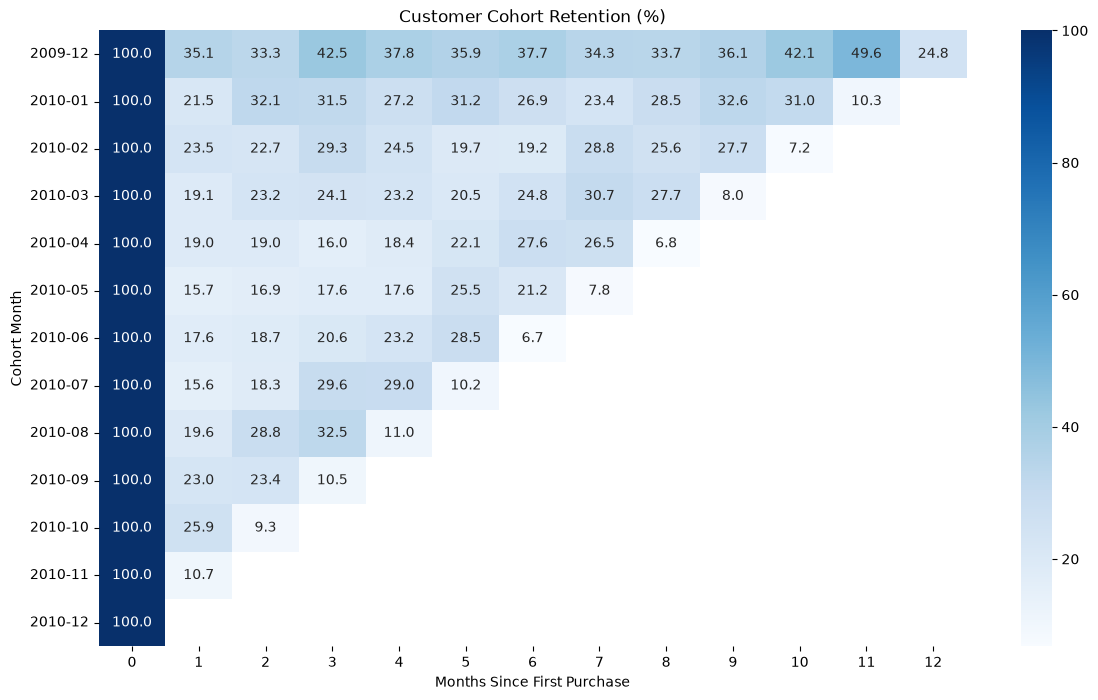

In [16]:
plt.figure(figsize=(14,8))

sns.heatmap(retention,annot=True,fmt=".1f",cmap="Blues")

plt.title("Customer Cohort Retention (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.savefig('Customer Cohort Retention (%).png',dpi=400)
plt.show()

## Business Insights

- Customer retention declines sharply after the first purchase, with only **15–25%** of customers returning in the following month. This indicates that improving the second purchase rate should be a key business priority.

- The **December 2009 cohort** exhibited the strongest long-term retention, with **35.1%** of customers returning after one month and nearly **49.6%** still purchasing after 11 months, suggesting a highly loyal customer base.

- Retention is **not consistently decreasing** across cohorts, indicating that many customers return after skipping one or more months. This reflects irregular purchasing behavior rather than permanent customer churn.

- Among the 2010 cohorts, **October 2010** recorded the highest Month-1 retention (**25.9%**), suggesting that customers acquired during this period were more engaged than those in other cohorts.

- Recent cohorts contain incomplete retention data because the dataset ends in **December 2010**, so their long-term performance cannot yet be fully evaluated.

### Key Takeaway
The analysis shows that while the business is effective at acquiring new customers, retaining them remains a significant opportunity. Strengthening customer retention through loyalty programs, personalized marketing, and re-engagement campaigns could substantially increase repeat purchases and long-term customer lifetime value (CLV).


## RFM Analysis

In [17]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2010-12-10 20:01:00')

In [18]:
# Create RFM table
rfm = (
    df.groupby("Customer ID").agg({
          "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
          "Invoice": "nunique",                                     # Frequency
          "Revenue": "sum"                                          # Monetary
      }).rename(columns={"InvoiceDate": "Recency","Invoice": "Frequency","Revenue": "Monetary"}).reset_index())
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,221.16
3,12349,43,2,2221.14
4,12351,11,1,300.93


In [19]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,4286.000000,4286.000000,4286.000000,4286.000000
mean,15356.195520,90.557163,4.428838,2025.306843
std,1700.111918,96.349049,7.944965,8829.842449
min,12346.000000,1.000000,1.000000,2.950000
25%,13890.250000,18.000000,1.000000,307.950000
50%,15361.500000,52.000000,2.000000,702.255000
75%,16839.750000,135.750000,5.000000,1703.985000
max,18287.000000,374.000000,184.000000,349164.350000


## Business Insights

- The customer base consists of **4,286 active customers** with an average recency of **91 days**, indicating that many customers have not made a recent purchase and may require re-engagement.

- The average customer places **4.4 orders**, while the median is only **2 orders**, showing that most customers purchase infrequently and a small group of loyal customers drives overall purchase frequency.

- Customer spending is highly skewed. Although the average customer generates **\$2,025** in revenue, the median is only **\$702**, indicating that a few high-value customers contribute a significant portion of total sales.

- The highest-spending customer generated over **\$349K** in revenue, highlighting the presence of a small but extremely valuable customer segment.

- Since the distributions of **Frequency** and **Monetary** are heavily right-skewed, RFM segmentation is essential to identify high-value customers, loyal customers, at-risk customers, and lost customers for targeted marketing strategies.


In [20]:
# score
rfm["R"] = pd.qcut(rfm["Recency"],q=5,labels=[5,4,3,2,1])
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5,labels=[1,2,3,4,5])
rfm["M"] = pd.qcut(rfm["Monetary"],q=5,labels=[1,2,3,4,5])
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R,F,M
0,12346,165,11,372.86,2,5,2
1,12347,3,2,1323.32,5,2,4
2,12348,74,1,221.16,2,1,1
3,12349,43,2,2221.14,3,2,5
4,12351,11,1,300.93,5,1,2


Frequency contains many duplicate values, which can prevent pd.qcut() from creating equal-sized quantile bins. Applying rank(method="first") assigns a unique rank to each customer while preserving the overall order, allowing qcut() to divide the data into five balanced groups without errors.

In [21]:
rfm["RFM Score"] = (rfm["R"].astype(str)+ rfm["F"].astype(str)+ rfm["M"].astype(str))
rfm

,Customer ID,Recency,Frequency,Monetary,R,F,M,RFM Score
0,12346,165,11,372.86,2,5,2,252
1,12347,3,2,1323.32,5,2,4,524
2,12348,74,1,221.16,2,1,1,211
3,12349,43,2,2221.14,3,2,5,325
4,12351,11,1,300.93,5,1,2,512
...,...,...,...,...,...,...,...,...
4281,18283,18,6,641.77,4,5,3,453
4282,18284,67,1,461.68,3,2,2,322
4283,18285,296,1,427.00,1,2,2,122
4284,18286,112,2,1296.43,2,3,4,234


In [22]:
def segment_customer(row):
    r = int(row["R"])
    f = int(row["F"])
    m = int(row["M"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f <= 3:
        return "Potential Loyalists"

    elif r >= 4 and f == 1:
        return "New Customers"

    elif r <= 2 and f >= 4:
        return "At Risk"

    elif r == 1 and f <= 2:
        return "Lost Customers"

    else:
        return "Need Attention"

In [23]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)
rfm

,Customer ID,Recency,Frequency,Monetary,R,F,M,RFM Score,Segment
0,12346,165,11,372.86,2,5,2,252,At Risk
1,12347,3,2,1323.32,5,2,4,524,Potential Loyalists
2,12348,74,1,221.16,2,1,1,211,Need Attention
3,12349,43,2,2221.14,3,2,5,325,Need Attention
4,12351,11,1,300.93,5,1,2,512,Potential Loyalists
...,...,...,...,...,...,...,...,...,...
4281,18283,18,6,641.77,4,5,3,453,Loyal Customers
4282,18284,67,1,461.68,3,2,2,322,Need Attention
4283,18285,296,1,427.00,1,2,2,122,Lost Customers
4284,18286,112,2,1296.43,2,3,4,234,Need Attention


In [24]:
rfm["Segment"].value_counts()

Segment
Need Attention         1280
Champions               921
Potential Loyalists     656
Lost Customers          636
Loyal Customers         471
At Risk                 322
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Segment'>

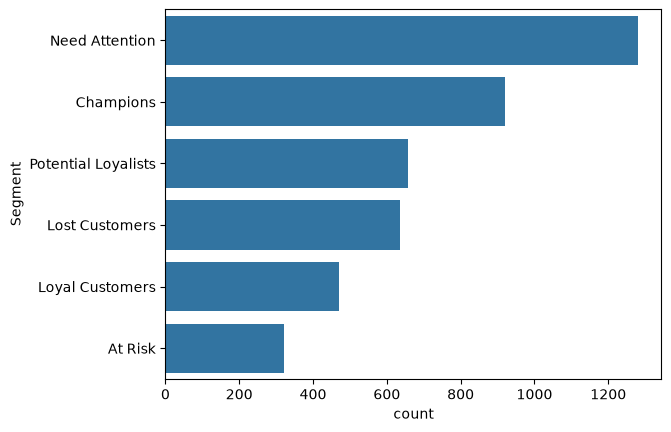

In [25]:
sns.countplot(data=rfm,y="Segment",order=rfm["Segment"].value_counts().index)

In [26]:
segment_summary = (rfm["Segment"].value_counts().reset_index())

segment_summary.columns = ["Segment", "Customers"]
segment_summary["Customer %"] = round(segment_summary["Customers"] / segment_summary["Customers"].sum() * 100, 2)
segment_summary

,Segment,Customers,Customer %
0,Need Attention,1280,29.86
1,Champions,921,21.49
2,Potential Loyalists,656,15.31
3,Lost Customers,636,14.84
4,Loyal Customers,471,10.99
5,At Risk,322,7.51


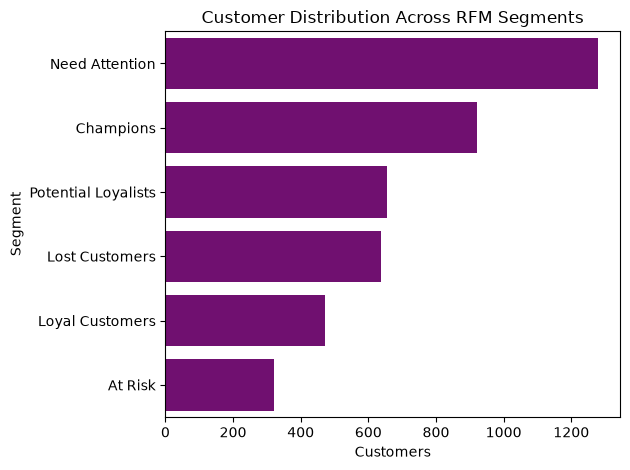

In [27]:
sns.barplot(data=segment_summary,y="Segment",x='Customers',color='purple')
plt.title("Customer Distribution Across RFM Segments")
plt.tight_layout()
plt.savefig('Customer Distribution Across RFM Segments.png',dpi=400)
plt.show()

##  Business Insights

- **Need Attention** is the largest segment, comprising **1,280 customers (29.86%)**. These customers have moderate engagement but are at risk of becoming inactive. Targeted promotions and personalized recommendations can help increase their purchase frequency.

- The business has **921 Champions (21.49%)**, its most valuable customers. These customers purchase frequently, spend the most, and should be retained through loyalty programs, exclusive offers, and early access to new products.

- **Potential Loyalists** account for **656 customers (15.31%)**. These customers have recently engaged with the business and have strong potential to become long-term loyal customers with timely follow-up campaigns.

- **Lost Customers** represent **636 customers (14.84%)**, indicating a considerable portion of the customer base has become inactive. Win-back campaigns and targeted discounts could help recover some of these customers.

- **Loyal Customers** make up **471 customers (10.99%)** and consistently contribute to business revenue. Maintaining strong relationships with this segment is essential for sustaining long-term growth.

- **At Risk** customers account for **322 customers (7.51%)**. These customers were previously active but have not purchased recently, making them ideal candidates for re-engagement campaigns before they churn completely.



##  Business Recommendations

Based on the analysis, the following recommendations can help improve business performance:

### 1. Improve Customer Retention
Nearly **30% of customers belong to the "Need Attention" segment**. Target these customers with personalized emails, limited-time discounts, and product recommendations to encourage repeat purchases before they become inactive.

### 2. Reward High-Value Customers
The **Champions** and **Loyal Customers** contribute significantly to revenue. Retain them through loyalty programs, exclusive offers, early access to new products, and VIP rewards to maximize Customer Lifetime Value (CLV).

### 3. Re-engage At-Risk and Lost Customers
Launch win-back campaigns for **At Risk** and **Lost Customers** using targeted discounts, reminder emails, or personalized offers to recover inactive customers and reduce churn.

### 4. Optimize Product Strategy
Focus inventory planning and promotional efforts on **top-selling products**, as a small percentage of products generate a large share of total revenue. Ensure these products remain well-stocked while reviewing low-performing products.

### 5. Expand High-Performing Markets
The **United Kingdom** dominates sales, while countries such as **EIRE, Netherlands, Germany, and France** show strong purchasing behavior. Invest in localized marketing campaigns and expand operations in these high-potential markets.

### 6. Increase Repeat Purchases
Cohort analysis shows customer retention declines sharply after the first purchase. Implement post-purchase engagement strategies, such as follow-up emails, cross-selling, and personalized recommendations, to improve the second purchase rate.

### 7. Drive Revenue Through Data-Driven Marketing
Leverage **RFM segmentation** to deliver personalized marketing campaigns instead of one-size-fits-all promotions. Different customer segments require different engagement strategies, leading to higher conversion rates and improved marketing ROI.

In [28]:
df["Customer ID"].nunique()

4286